# Notebook 2: Inspecting and convolving a SKIRT datacube with S-PLUS filters
**Author:** Gustavo Fernandes Gonçalves
ORCID: [0009-0006-5887-6621](https://orcid.org/0009-0006-5887-6621)
Lattes: http://lattes.cnpq.br/7416443230735445

This notebook provides a step-by-step guide on how to open a spectral data cube generated by SKIRT, view it in several different ways, and generate synthetic images in the 12 S-PLUS bands.

## 1. Selecting the file

In [2]:
from astropy.io import fits
from astropy.visualization import PercentileInterval, ImageNormalize, AsinhStretch
import numpy as np
import matplotlib.pyplot as plt
 
from tutorial_tools import get_splus_filters, load_transmission, make_2d_header, connect_ds9, interactive_slit, convolve_filter
 
base_dir = './SKIRT_datacubes'
subhalo_id = '10'  # <- Replace this with your subhalo ID
 
path = f'{base_dir}/{subhalo_id}_splus_cube_total.fits.gz'
 
hdu = fits.open(path)

## 2. General Info and Data Format

In [3]:
hdu.info()

Filename: ./SKIRT_datacubes/10/10_splus_cube_total.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      32   (600, 600, 1500)   float32   
  1  Z-axis coordinate values    1 TableHDU        13   1500R x 1C   [E16.9]   


Wavelength: HDU 1 (table).

In [4]:
hdu[1].columns

ColDefs(
    name = 'GRID_POINTS'; format = 'E16.9'; unit = 'micron'; start = 1
)

In [5]:
data = hdu[0].data
header = hdu[0].header
wave = hdu[1].data[hdu[1].columns.names[0]] * 1e4  # micron -> Å
 
data.shape, wave.shape, wave.min(), wave.max()

((1500, 600, 600), (1500,), 3000.0, 10500.0)

## 3. Data cube slice at a specific wavelength

Text(0.5, 1.0, '6637.4 Å')

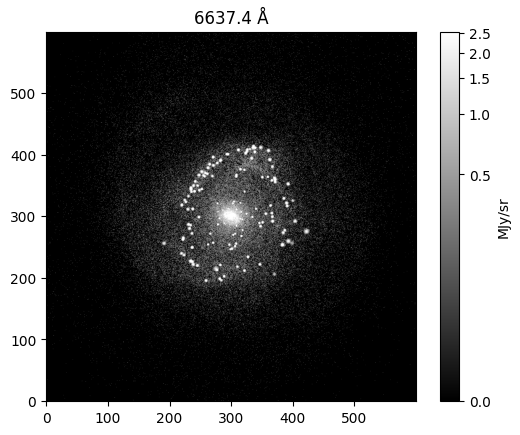

In [6]:
idx = np.argmin(np.abs(wave - 6637))  # wavelength in Å
 
plt.imshow(data[idx], origin='lower', cmap='gray', norm=ImageNormalize(data[idx], interval=PercentileInterval(99.5), stretch=AsinhStretch(0.03)))
plt.colorbar(label='MJy/sr')
plt.title(f'{wave[idx]:.1f} Å')

## 4. Integrated spectrum

In [7]:
img_white = data.mean(axis=0)  # broadband image (all simulated wavelengths)

The spectrum below represents the average brightness across **all pixels in the image**, that is, across the instrument’s entire field of view. The panel on the left shows this region; the one on the right shows the resulting spectrum.

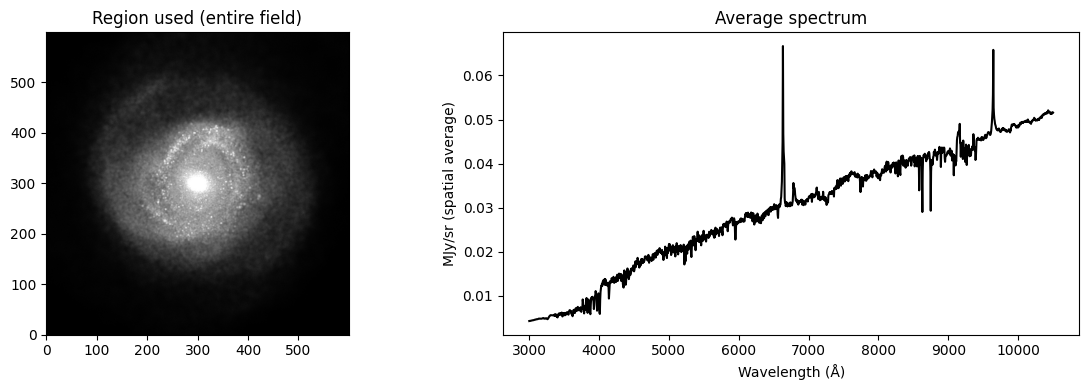

In [8]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4))
 
axL.imshow(img_white, origin='lower', cmap='gray', norm=ImageNormalize(img_white, interval=PercentileInterval(99.5), stretch=AsinhStretch(0.03)))
axL.set_title('Region used (entire field)')
 
spectrum = data.mean(axis=(1, 2))
axR.plot(wave, spectrum, color='black')
axR.set_xlabel('Wavelength (Å)')
axR.set_ylabel('MJy/sr (spatial average)')
axR.set_title('Average spectrum')
 
plt.tight_layout()

### 4.1 Spectrum of a Region

In [9]:
slit = interactive_slit(img_white)

interactive(children=(IntSlider(value=20, description='width', max=600, min=1), IntSlider(value=300, descripti…

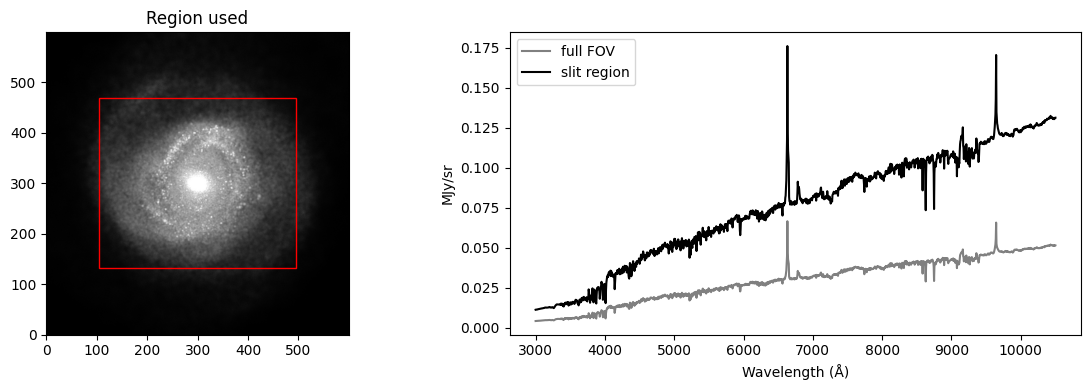

In [10]:
from matplotlib.patches import Rectangle
 
x0, x1 = slit['xc'] - slit['width'] // 2, slit['xc'] + slit['width'] // 2
y0, y1 = slit['yc'] - slit['length'] // 2, slit['yc'] + slit['length'] // 2
 
spectrum_slit = data[:, y0:y1, x0:x1].mean(axis=(1, 2))
 
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4))
 
axL.imshow(img_white, origin='lower', cmap='gray', norm=ImageNormalize(img_white, interval=PercentileInterval(99.5), stretch=AsinhStretch(0.03)))
axL.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, edgecolor='red', facecolor='none'))
axL.set_title('Region used')
 
axR.plot(wave, spectrum, color='gray', label='full FOV')
axR.plot(wave, spectrum_slit, color='black', label='slit region')
axR.set_xlabel('Wavelength (Å)')
axR.set_ylabel('MJy/sr')
axR.legend()
 
plt.tight_layout()

## 5. Filter Curves

In [11]:
base = './filter_curves-master'

filters = get_splus_filters(base)

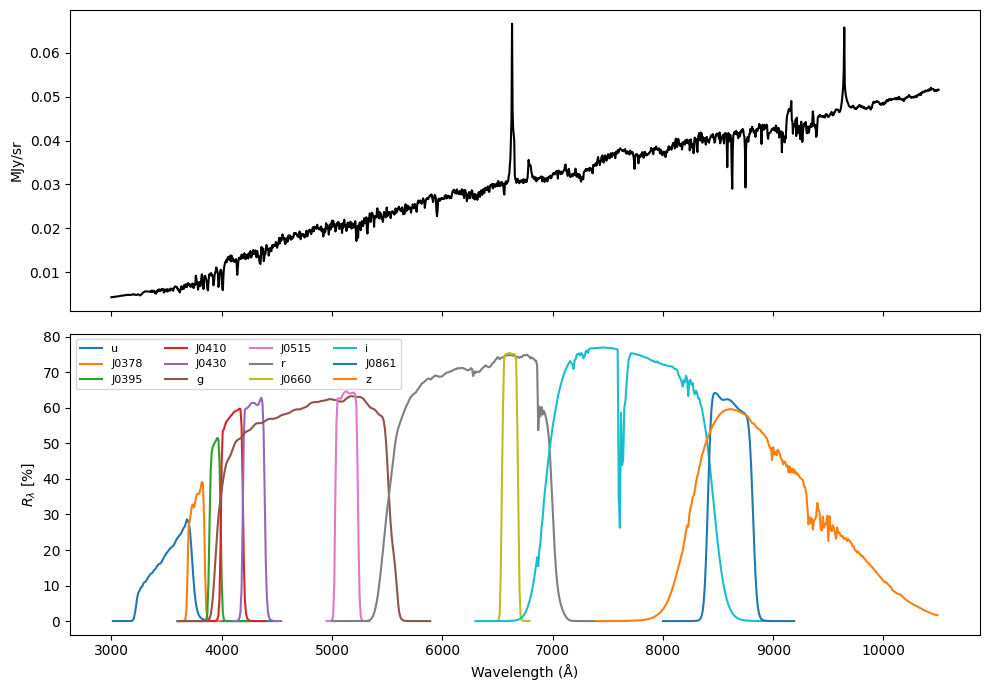

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
 
ax1.plot(wave, spectrum, color='black')
ax1.set_ylabel('MJy/sr')
 
for name, filt_path in filters.items():
    filt_wave, filt_resp = load_transmission(filt_path)
    ax2.plot(filt_wave, filt_resp * 100, label=name)
 
ax2.set_xlabel('Wavelength (Å)')
ax2.set_ylabel(r'$R_\lambda$ [%]')
ax2.legend(ncol=4, fontsize=8)
 
plt.tight_layout()

## 6. Convolution with a filter

$$f_{\text{banda}} = \frac{\int f_\lambda\, T(\lambda)\, d\lambda}{\int T(\lambda)\, d\lambda}, \qquad T = \lambda R_\lambda$$
 
`convolve_filter`, at `tutorial_tools.py`.

For photon counters, $T(\lambda) = \lambda R(\lambda)$ ([SKIRT/PTS BroadBand](https://skirt.ugent.be/pts9/classpts_1_1band_1_1broadband_1_1_broad_band.html)).

## 7. Generating the FITS files for each filter, one at a time


In [ ]:
filter_name = 'g'  # <- Replace with any SPLUS filter name
 
img = convolve_filter(wave, data, filters[filter_name])
 
plt.imshow(img, origin='lower', cmap='gray', norm=ImageNormalize(img, interval=PercentileInterval(99.5), stretch=AsinhStretch(0.03)))
plt.colorbar(label='MJy/sr')
plt.title(filter_name)

In [ ]:
import os
 
hdr = make_2d_header(header, subhalo_id)
 
outdir = f'fits_noisefree/{subhalo_id}'
os.makedirs(outdir, exist_ok=True)
 
fits.PrimaryHDU(img.astype('float32'), header=hdr).writeto(f'{outdir}/{subhalo_id}_{filter_name}.fits', overwrite=True)

## 8. Showing on DS9
`sudo apt install saods9 xpa-tools` and `pip install pyds9` required. The first time you use it, you may need to register it under **File → XPA → Connect**.

In [ ]:
d = connect_ds9()

This opens the FITS file for the filter specified in `filter_name` (the same one used in the previous step) in DS9. Replace `filter_name` and run this cell. Each run opens a new frame, so you can compare the filters one by one.

In [ ]:
filter_name = 'g' 

d.set('tile yes')
d.set('frame new')
d.set(f'file {outdir}/{subhalo_id}_{filter_name}.fits')